In [3]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Save Model
import pickle

In [5]:
# Load the dataset
df = pd.read_csv("../data/heart.csv")

# Display first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [16]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(723)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

In [13]:
(df["target"].value_counts(normalize=True) * 100).round(2)

target
1    54.3
0    45.7
Name: proportion, dtype: float64

In [14]:
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
570,54,0,2,135,304,1,1,170,0,0.0,2,0,2,1
161,51,1,2,100,222,0,1,143,1,1.2,1,0,2,1
282,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
271,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
56,56,1,3,120,193,0,0,162,0,1.9,1,0,3,1


In [15]:
df.head()

df.columns

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


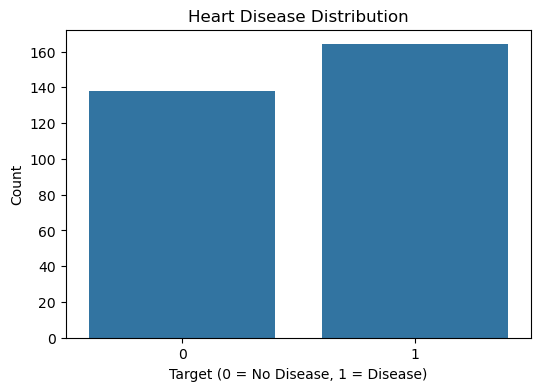

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()

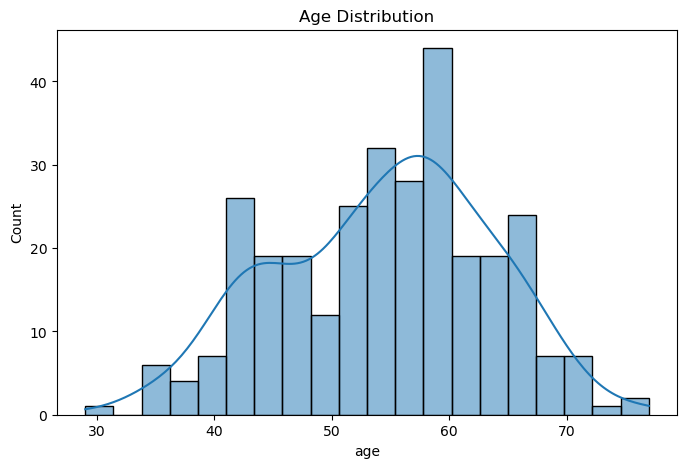

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

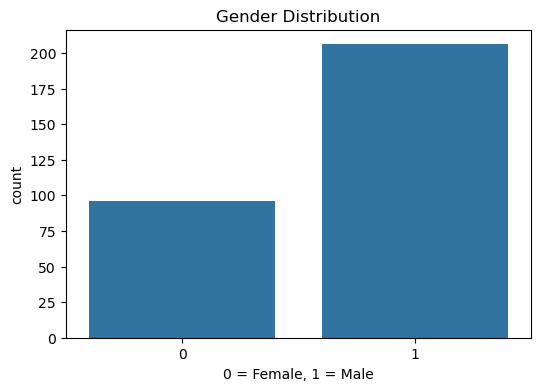

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='sex', data=df)
plt.title("Gender Distribution")
plt.xlabel("0 = Female, 1 = Male")
plt.show()

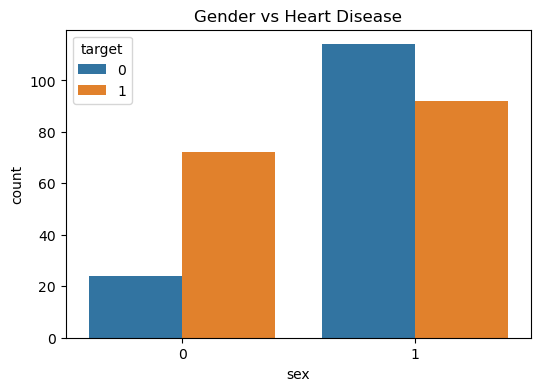

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='sex', hue='target', data=df)
plt.title("Gender vs Heart Disease")
plt.show()

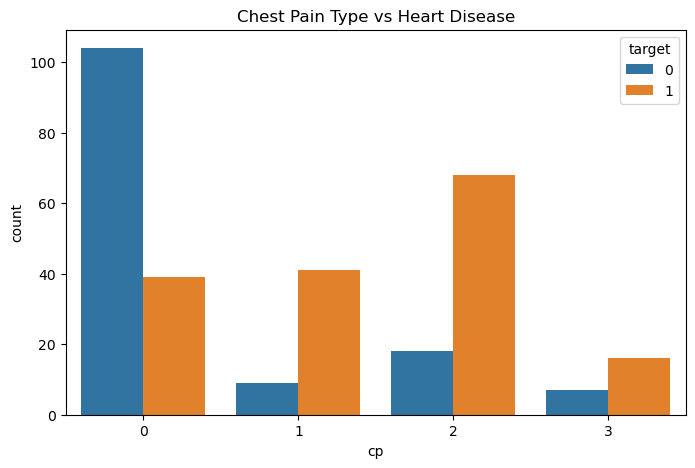

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x='cp', hue='target', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

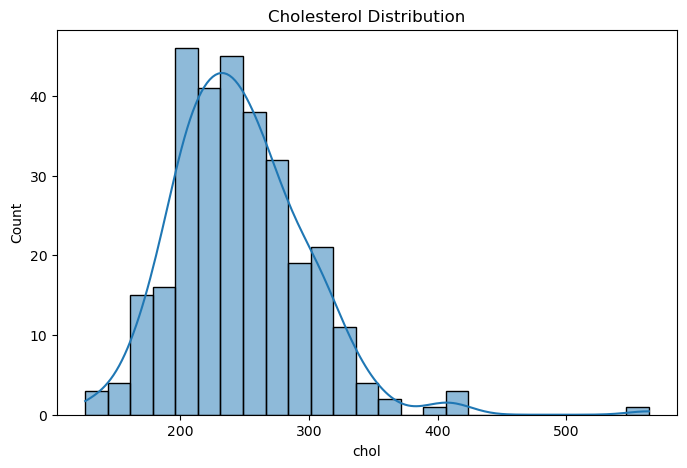

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['chol'], bins=25, kde=True)
plt.title("Cholesterol Distribution")
plt.show()

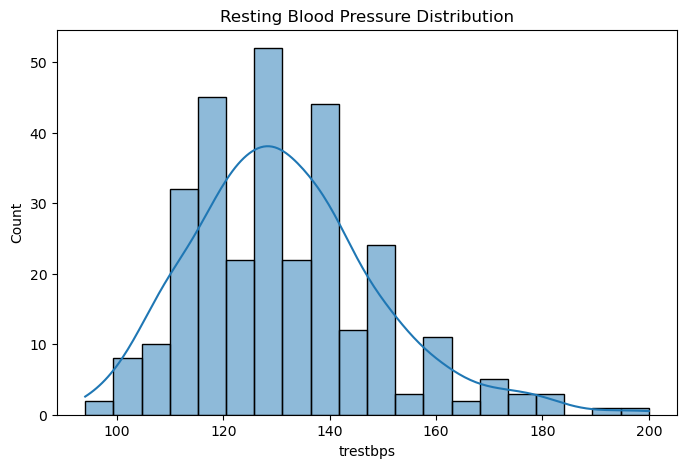

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['trestbps'], bins=20, kde=True)
plt.title("Resting Blood Pressure Distribution")
plt.show()

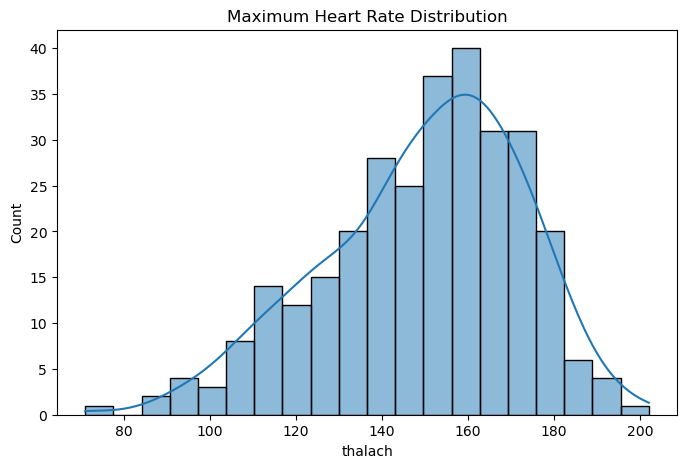

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['thalach'], bins=20, kde=True)
plt.title("Maximum Heart Rate Distribution")
plt.show()

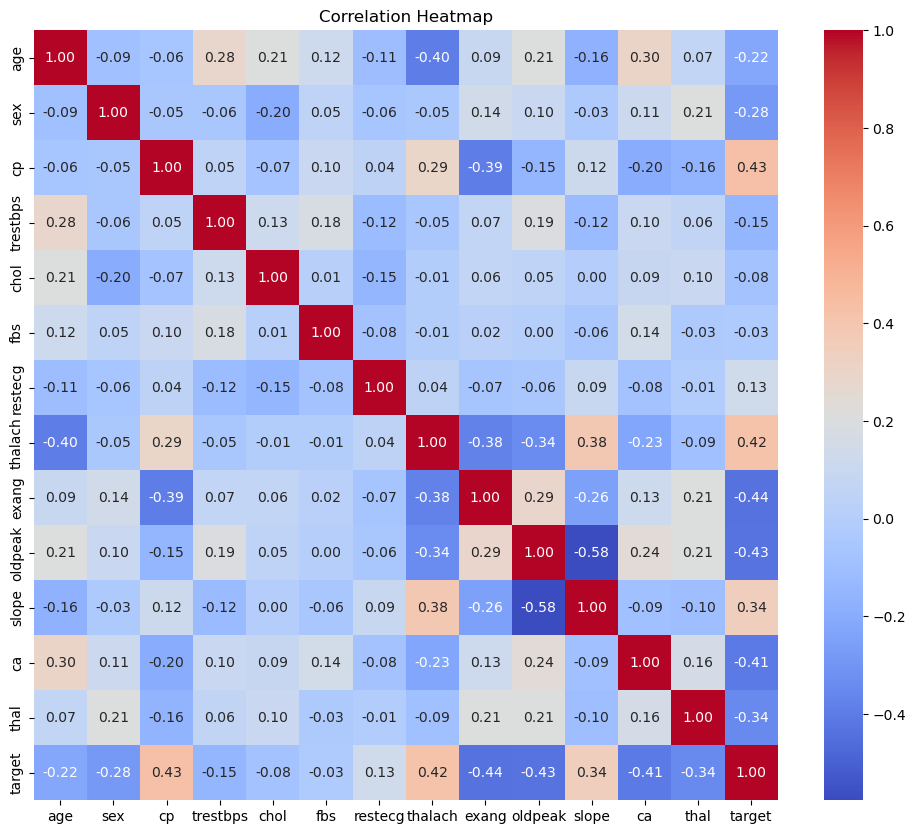

In [25]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [26]:
X = df.drop("target", axis=1)
y = df["target"]

In [27]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (241, 13)
X_test : (61, 13)
y_train: (241,)
y_test : (61,)


In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}

In [32]:
results = []

for name, model in models.items():

    # Use scaled data only for LR and SVM
    if name in ["Logistic Regression", "SVM"]:
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

In [33]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529,0.871212
1,Decision Tree,0.803279,0.818182,0.818182,0.818182,0.801948
2,SVM,0.770492,0.771429,0.818182,0.794118,0.841991
3,Random Forest,0.754098,0.764706,0.787879,0.776119,0.861472
4,XGBoost,0.721311,0.735294,0.757576,0.746269,0.832251


In [34]:
results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "ROC AUC": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8033,0.8000,0.8485,0.8235,0.8712
1,Decision Tree,0.8033,0.8182,0.8182,0.8182,0.8019
2,Random Forest,0.7541,0.7647,0.7879,0.7761,0.8615
3,SVM,0.7705,0.7714,0.8182,0.7941,0.8420
4,XGBoost,0.7213,0.7353,0.7576,0.7463,0.8323


best_model = LogisticRegression(max_iter=1000, random_state=42)

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

In [38]:
best_model = LogisticRegression(max_iter=1000, random_state=42)

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



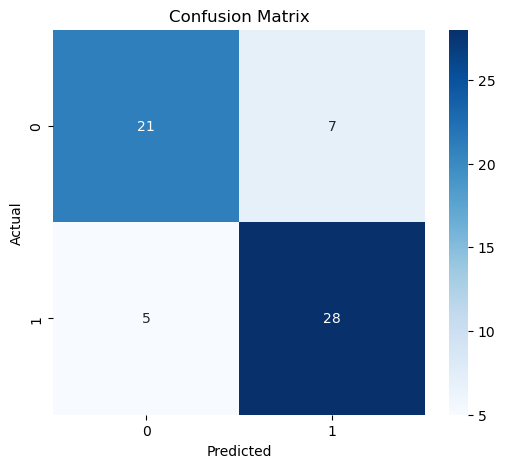

In [40]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [41]:
y_prob = best_model.predict_proba(X_test_scaled)[:,1]

print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

ROC AUC Score: 0.8712121212121212


In [42]:
import pickle

pickle.dump(best_model, open("../models/model.pkl", "wb"))
pickle.dump(scaler, open("../models/scaler.pkl", "wb"))

print("Model Saved Successfully!")

Model Saved Successfully!


In [43]:
import os

print(os.listdir("../models"))

['model.pkl', 'scaler.pkl']


In [45]:
import streamlit as st
import pickle
import numpy as np

# Load model and scaler
model = pickle.load(open("../models/model.pkl", "rb"))
scaler = pickle.load(open("../models/scaler.pkl", "rb"))

st.set_page_config(page_title="Heart Disease Prediction", page_icon="❤️", layout="centered")

st.title("❤️ Heart Disease Prediction System")
st.write("Enter the patient's medical information to predict the risk of heart disease.")

# Input fields
age = st.number_input("Age", 20, 100, 50)

sex = st.selectbox("Sex", ["Female", "Male"])
sex = 1 if sex == "Male" else 0

cp = st.selectbox(
    "Chest Pain Type",
    [0, 1, 2, 3],
    help="0=Typical Angina, 1=Atypical Angina, 2=Non-anginal Pain, 3=Asymptomatic"
)

trestbps = st.number_input("Resting Blood Pressure (mm Hg)", 80, 250, 120)

chol = st.number_input("Serum Cholesterol (mg/dl)", 100, 600, 240)

fbs = st.selectbox("Fasting Blood Sugar > 120 mg/dl", [0, 1])

restecg = st.selectbox("Resting ECG Results", [0, 1, 2])

thalach = st.number_input("Maximum Heart Rate Achieved", 60, 220, 150)

exang = st.selectbox("Exercise Induced Angina", [0, 1])

oldpeak = st.number_input("ST Depression", 0.0, 6.5, 1.0, step=0.1)

slope = st.selectbox("Slope of Peak Exercise ST Segment", [0, 1, 2])

ca = st.selectbox("Number of Major Vessels (0–4)", [0, 1, 2, 3, 4])

thal = st.selectbox("Thalassemia", [0, 1, 2, 3])

if st.button("Predict"):

    features = np.array([[age, sex, cp, trestbps, chol,
                          fbs, restecg, thalach,
                          exang, oldpeak, slope,
                          ca, thal]])

    features = scaler.transform(features)

    prediction = model.predict(features)
    probability = model.predict_proba(features)[0][1]

    st.subheader("Prediction Result")

    if prediction[0] == 1:
        st.error("⚠️ High Risk of Heart Disease")
    else:
        st.success("✅ Low Risk of Heart Disease")

    st.write(f"**Prediction Probability:** {probability:.2%}")

2026-06-30 15:05:00.822 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 15:05:00.823 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 15:05:00.940 
  command:

    streamlit run c:\Users\Lenovo\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-30 15:05:00.941 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 15:05:00.942 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 15:05:00.943 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 15:05:00.945 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when run